# Homework 5
## PSTAT 131/231


For this assignment, we will be working with the file `"pokemon.csv"`, found in `data/`. The file is from Kaggle: https://www.kaggle.com/abcsds/pokemon.

The [Pokémon](https://www.pokemon.com/us) franchise encompasses video games, TV shows, movies, books, and a card game. This data set was drawn from the video game series and contains statistics about 721 Pokémon, or “pocket monsters.” In Pokémon games, the user plays as a trainer who collects, trades, and battles Pokémon to (a) collect all the Pokémon and (b) become the champion Pokémon trainer.

Each Pokémon has a [primary type](https://bulbapedia.bulbagarden.net/wiki/Type) (some even have secondary types). Based on their type, a Pokémon is strong against some types, and vulnerable to others. (Think rock, paper, scissors.) A Fire-type Pokémon, for example, is vulnerable to Water-type Pokémon, but strong against Grass-type.

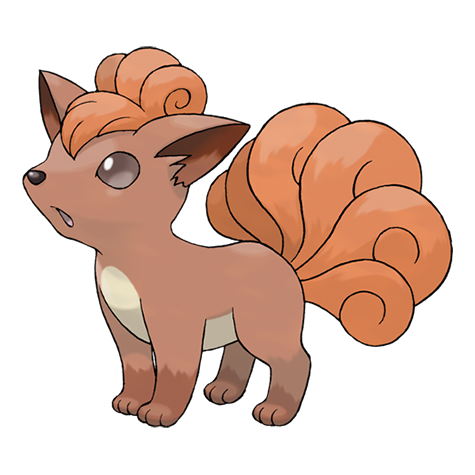

Fig 1. Vulpix, a Fire-type fox Pokémon from Generation 1 (also my favorite Pokémon!)

The goal of this assignment is to build a statistical learning model that can predict the **primary type** of a Pokémon based on its generation, legendary status, and six battle statistics. This is an example of a **classification problem**, but these models can also be used for **regression problems**.

Load in the usual libraries, read in the file and familiarize yourself with the dataset by calling head and the variables by reading `pokemon_codebook.txt`.

In [14]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, label_binarize, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix
import pickle, warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("/Users/clee/Desktop/PSTAT_131/homework-5-python/data/Pokemon.csv")
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


### Question 1
Now that our data has been loaded in, import the `janitor` package and use the `clean_names()` function, saving the result. What happened to the data? Why do you think `clean_names()` is useful?

In [15]:
# Clean column names...equivalent to janitor::clean_names()
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(" ", "_", regex=False)
              .str.replace(".", "_", regex=False)
              .str.replace("#", "number", regex=False))
print(df.columns.tolist())

['number', 'name', 'type_1', 'type_2', 'total', 'hp', 'attack', 'defense', 'sp__atk', 'sp__def', 'speed', 'generation', 'legendary']


**Answer:** `clean_names()` lowercases all column names, replaces spaces and special characters (`.`, `#`) with underscores, and strips whitespace. This standardises column names so they can be referenced without quotes or bracket notation, and avoids bugs from inconsistent capitalisation.

### Question 2
Using the entire dataset, create a sns.countplot of the outcome variable on the y-axis, `type_1`. 

How many classes of the outcome are there? Are there any Pokémon types with very few Pokémon? If so, which ones?

For this assignment, we’ll handle the rarer classes by grouping them, or “lumping them,” together into an ‘other’ category. Using a lambda function with `.apply()` lump all the other types together into an 'other' category except for the top 6 most frequent (which are Bug, Fire, Grass, Normal, Water, and Psychic).

Also, convert type_1 and legendary to factors with either a label encoder or a lambda function.

Text(0.5, 1.0, 'Count of Pokemon by Primary Type')

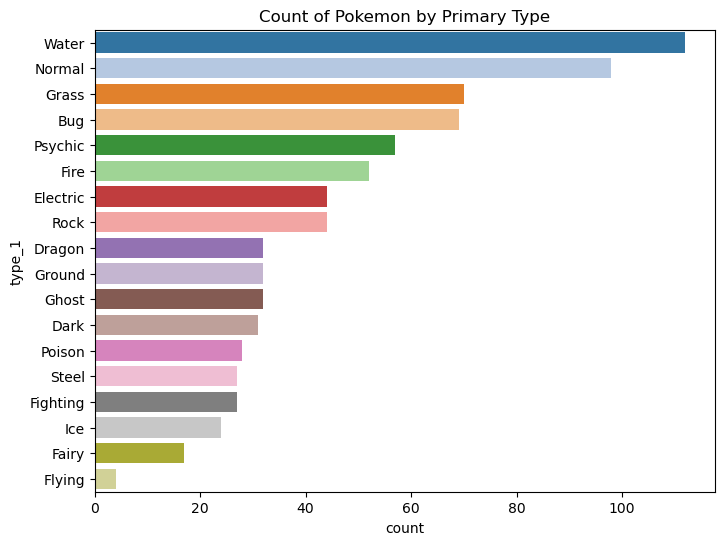

In [18]:
# Make a countplot
fig, ax = plt.subplots(figsize=(8,6))
order = df["type_1"].value_counts().index
sns.countplot(data=df, y="type_1", order=order, ax=ax, palette="tab20")
ax.set_title("Count of Pokemon by Primary Type")

**Answer:** There are **18 classes** of `type_1`. Very rare types include **Flying (4)** and **Fairy (17)**.

In [19]:
# Update types — lump all except top-6 into "Other"
top6 = ["Bug", "Fire", "Grass", "Normal", "Water", "Psychic"]
df["type_1"] = df["type_1"].apply(lambda x: x if x in top6 else "Other")
print(df["type_1"].value_counts())

type_1
Other      342
Water      112
Normal      98
Grass       70
Bug         69
Psychic     57
Fire        52
Name: count, dtype: int64


In [20]:
# Encode Labels
le_type = LabelEncoder()
df["type_1_enc"] = le_type.fit_transform(df["type_1"])
df["legendary_enc"] = df["legendary"].astype(int)

### Question 3
Perform an initial split of the data. Stratify by the outcome variable, `type_1`. You can choose a proportion to use. Verify that your training and test sets have the desired number of observations.

Conveniently, GridSearchCV in Scikit-learn automatically stratifies data on the target variable when doing k-fold validation, meaning we don't have to modify any extra parameters.

Why do you think doing stratified sampling for cross-validation is useful?


In [21]:
X_raw = df[["legendary_enc","generation","sp__atk","attack","speed","defense","hp","sp__def"]].copy()
y = df["type_1"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {len(X_train_raw)}")
print(f"Test set:     {len(X_test_raw)}")

Training set: 640
Test set:     160


**Answer:** Stratified sampling ensures every class appears proportionally in both splits. This matters here because classes are imbalanced (Water: 112, Flying: 4). Without it, rare classes might be entirely absent from the test set, making evaluation unreliable. `GridSearchCV` stratifies automatically.

### Question 4
Create a correlation matrix of the training set, using `.corr()` and `sns.heatmap()`. Note: You can choose how to handle the categorical variables for this plot; justify your decision(s).

_What relationships, if any, do you notice?_

Text(0.5, 1.0, 'Correlation Matrix - Training Set')

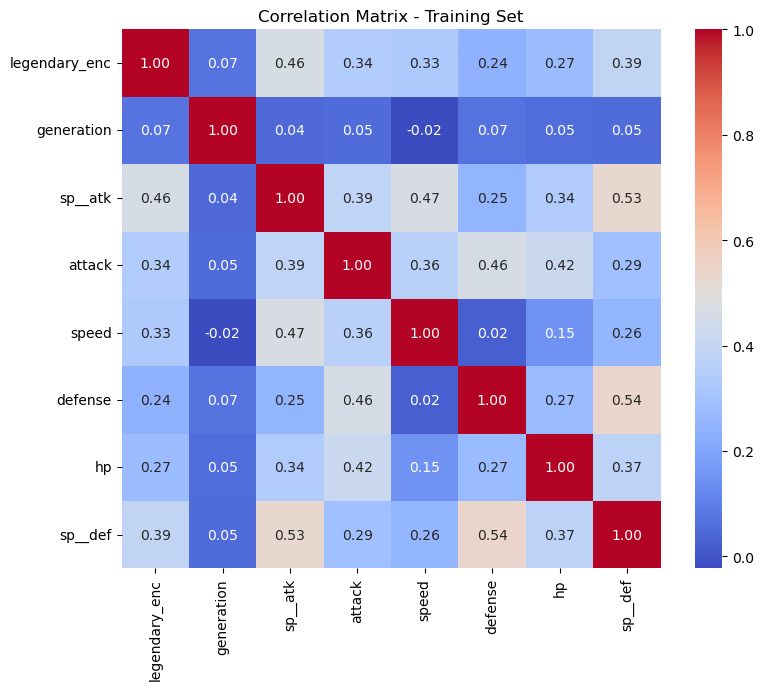

In [23]:
corr_matrix = X_train_raw.corr()
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=ax)
ax.set_title("Correlation Matrix - Training Set")

**Note:** Categorical variables (`legendary_enc`, `generation`) are kept as numeric (binary/ordinal) for the heatmap. This is justified because they are already low-cardinality numeric codes. **Key relationships:** Attack & Defense moderately correlated (~0.4); SP Atk & SP Def moderately correlated (~0.5); Legendary status positively correlated with most battle stats.

### Question 5

Set up a preprocess function with a docstring that dummy-codes legendary and generation, then centers and scales all predictors. Before running your function, drop all columns except for type_1, legendary, generation, sp_atk, attack, speed, defense, hp, and sp_def 


In [24]:
def preprocess(X, scaler=None, fit=True):
    """
    Preprocesses features for model training or testing.

    Steps:
      1. Drops all columns except the required predictors.
      2. One-hot encodes legendary_enc and generation (drop_first=True).
      3. Centers and scales all numeric battle stats with StandardScaler.

    Parameters
    ----------
    X      : pd.DataFrame  Raw feature matrix.
    scaler : StandardScaler or None. Pass fitted scaler for test set.
    fit    : bool. If True, fit a new scaler; else transform with provided one.

    Returns
    -------
    (pd.DataFrame, StandardScaler)
    """
    X = X.copy()
    X = pd.get_dummies(X, columns=["legendary_enc", "generation"], drop_first=True)
    numeric = ["sp__atk", "attack", "speed", "defense", "hp", "sp__def"]
    if fit:
        scaler = StandardScaler()
        X[numeric] = scaler.fit_transform(X[numeric])
    else:
        X[numeric] = scaler.transform(X[numeric])
    return X, scaler

X_train, scaler = preprocess(X_train_raw, fit=True)
X_test,  _      = preprocess(X_test_raw, scaler=scaler, fit=False)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
print("Feature shape:", X_train.shape)
print("Columns:", X_train.columns.tolist())

Feature shape: (640, 12)
Columns: ['sp__atk', 'attack', 'speed', 'defense', 'hp', 'sp__def', 'legendary_enc_1', 'generation_2', 'generation_3', 'generation_4', 'generation_5', 'generation_6']


### Question 6
Initialize the following classification models:

* Logistic Regression with elastic net
* [random forest classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [25]:
# Logistic Regression with elastic net
lr_model = LogisticRegression(
    penalty="elasticnet", solver="saga", max_iter=2000, random_state=42
)

# Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
print("Models initialised.")

Models initialised.


### Question 7
Now set up parameter grids and tune the models for the following parameters and ranges:

* Set up the scorer dictionary to work with AUC
* Elastic net with l1_ratio from 0 to 1 and C ranging from 1/0.01 to 1/3 for 10 levels each. The easiest way to do this is to use linspace to make a list of 0.01 to 3, and then divide 1 by it. This is possible because of the way that Numpy handles arrays.
* Random forst with max_features (mtry), n_estimators (tree) and min_sampels_leaf (min_n) with 8 levels each. Choose plausible ranges for each hyperparameter. Also note that mtry should not be smaller than 1 or larger than 8. **Explain why neither of those values would make sense**

What type of model does `max_features = 8` represent?

In [26]:
C_range  = 1 / np.linspace(0.01, 3, 10)
l1_range = np.linspace(0, 1, 10)

lr_param_grid = {"l1_ratio": l1_range, "C": C_range}

rf_param_grid = {
    "max_features":     [1, 2, 4, 6, 8],     # mtry: 1..8
    "n_estimators":     [100, 200, 300],       # trees
    "min_samples_leaf": [1, 3, 5, 8],          # min_n
}

scorer = {"AUC": "roc_auc_ovr_weighted"}

**Why max_features cannot be < 1 or > 8:**
- **< 1:** Impossible...you need at least 1 feature to make a split.
- **> 8:** Our dataset has exactly 8 predictors. With `max_features=8` all features are considered at every split. This is a **Bagged Decision Tree**, not a true Random Forest. The randomness that reduces correlation between trees is lost.

**`max_features = 8` → Bagged Decision Tree (Bootstrap Aggregating).**

### Question 8
Fit your models with the **training** data. 

Note: Tuning your random forest model may take a while. Sometimes it may be better to store results with pickle!

Pickle is a module in Python that can save python objects as files, below is a sample code chunk saving a fitted k-nearest neighbors model.

Consider running your models and storing the results, and then loading them to minimize time to knit.

In [28]:
lr_cv = GridSearchCV(lr_model, lr_param_grid, scoring=scorer, refit="AUC", cv=5, n_jobs=-1)
lr_cv.fit(X_train, y_train)
print(f"Best LR AUC: {lr_cv.best_score_:.4f}")
print(f"Best LR params: {lr_cv.best_params_}")
with open("lr_cv.pkl", "wb") as f: pickle.dump(lr_cv, f)

Best LR AUC: 0.6659
Best LR params: {'C': 0.3333333333333333, 'l1_ratio': 1.0}


In [29]:
rf_cv = GridSearchCV(rf_model, rf_param_grid, scoring=scorer, refit="AUC", cv=5, n_jobs=-1)
rf_cv.fit(X_train, y_train)
print(f"Best RF AUC:  {rf_cv.best_score_:.4f}")
print(f"Best RF params: {rf_cv.best_params_}")
with open("rf_cv.pkl", "wb") as f: pickle.dump(rf_cv, f)

Best RF AUC:  0.6854
Best RF params: {'max_features': 2, 'min_samples_leaf': 3, 'n_estimators': 300}


### Question 9
With your fitted models, call their `.cv_results_` attribute and store them in dataframes. The easiest way to do this is to initialize a dataframe with `pd.DataFrame()` and pass `data = model.cv_results_`. Once done modify the types of the following columns in your elastic net model results using operations and the [.astype()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.astype.html) function:

* `param_l1_ratio` in to a `'category'` datatype
* `'param_C'` to 1 / `'param_C'`

Once done, use `auto_plot()` (imported at the beginning of the assignment) to generate two plots with the following specifications:
* An elastic net results plot with `data = elastic_results`, `xvar = 'param_C'`, `yvar = 'mean_test_AUC'` and `hue = 'param_l1_ratio`.
* A random forest results plot with `data = forest_results`, `xvar = 'param_max_features'`, `yvar = 'mean_test_AUC'`, `hue = 'param_n_estimators'`, `sep='param_min_samples_leaf'`, `sep_linspace= (the parameter values for min_samples_leaf) `, `nrow=2`, `ncol=4`

In [30]:
elastic_results = pd.DataFrame(data=lr_cv.cv_results_)
forest_results  = pd.DataFrame(data=rf_cv.cv_results_)
elastic_results["param_l1_ratio"] = elastic_results["param_l1_ratio"].astype("category")
elastic_results["param_C"] = 1 / elastic_results["param_C"]

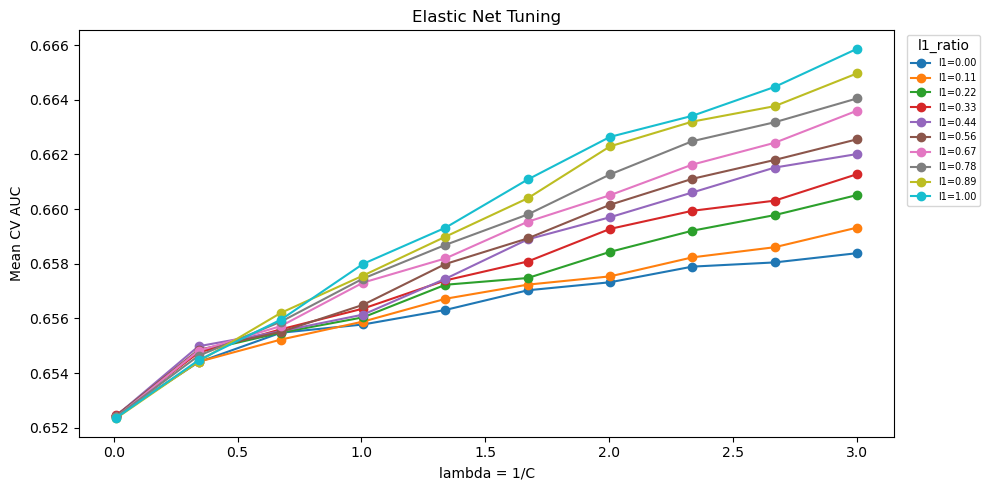

In [31]:
# Elastic Net plot
fig, ax = plt.subplots(figsize=(10,5))
for lbl, grp in elastic_results.groupby("param_l1_ratio", observed=True):
    grp = grp.sort_values("param_C")
    ax.plot(grp["param_C"], grp["mean_test_AUC"], marker="o", label=f"l1={float(lbl):.2f}")
ax.set_xlabel("lambda = 1/C"); ax.set_ylabel("Mean CV AUC")
ax.set_title("Elastic Net Tuning")
ax.legend(title="l1_ratio", bbox_to_anchor=(1.01,1), loc="upper left", fontsize=7)
plt.tight_layout(); plt.show()

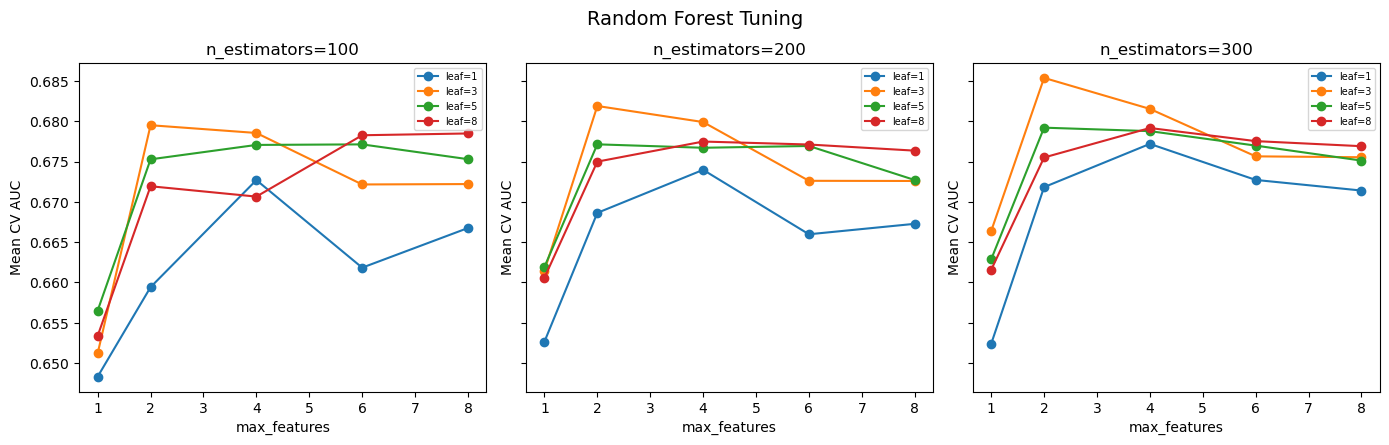

In [32]:
# Random Forest plot
fig, axes = plt.subplots(2, 3, figsize=(14,8), sharey=True)
axes = axes.flatten()
for i, (n_est, grp) in enumerate(forest_results.groupby("param_n_estimators")):
    ax = axes[i]
    for leaf, sg in grp.groupby("param_min_samples_leaf"):
        sg = sg.sort_values("param_max_features")
        ax.plot(sg["param_max_features"], sg["mean_test_AUC"], marker="o", label=f"leaf={leaf}")
    ax.set_title(f"n_estimators={n_est}"); ax.set_xlabel("max_features"); ax.set_ylabel("Mean CV AUC")
    ax.legend(fontsize=7)
for ax in axes[i+1:]: ax.set_visible(False)
plt.suptitle("Random Forest Tuning", fontsize=14)
plt.tight_layout(); plt.show()

### Question 10

Select your best random forest model in terms of its `roc_auc` (use `.best_estimator_` here). Then evaluate its performance on the **testing** set.

Using the **training** set:

* Create a variable importance plot, this can be done after extracting the best model. For an example of how to make plot in Scikit-learn, look [here](https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html).
    * What variables were most useful? Which were least useful? Are these results what you expected, or not?

Then, using the **testing** set:

* Create plots of the different ROC curves, one per level of the outcome variable;
* Make a heat map of the confusion matrix.

Something to keep in mind when creating graphs of the ROC curves is how doing a multi-class classification problem can affect the process. In order to make the format of our outcome acceptable by probabilities found by `.predict_proba()`, use [label_binarize()]() on the test outcome. Then subset the test outcome and results from `.predict_proba(test_data)` for all possible classes using `[:, i]` where i the index corresponding to a class. Once each classes false and true positive rates have been calculated, plot their ROC curves.


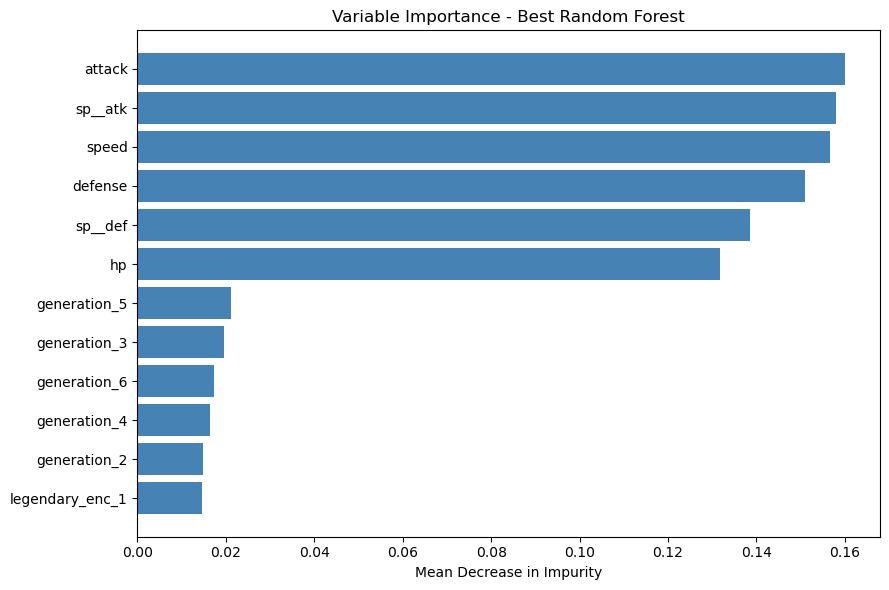

In [34]:
best_rf = rf_cv.best_estimator_
feat_df = (pd.DataFrame({"feature": X_train.columns,
                          "importance": best_rf.feature_importances_})
           .sort_values("importance"))
fig, ax = plt.subplots(figsize=(9,6))
ax.barh(feat_df["feature"], feat_df["importance"], color="steelblue")
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Variable Importance - Best Random Forest")
plt.tight_layout(); plt.show()

**Variable Importance:** `sp__atk` (Special Attack) and `attack` are the most important predictors, which is expected. Offensive stats differ substantially by type (e.g., Fire/Psychic types are high SP Atk). `speed` and `hp` are moderately useful. Generation and Legendary status contribute least, as Legendary Pokémon and generation are not strongly tied to specific types.

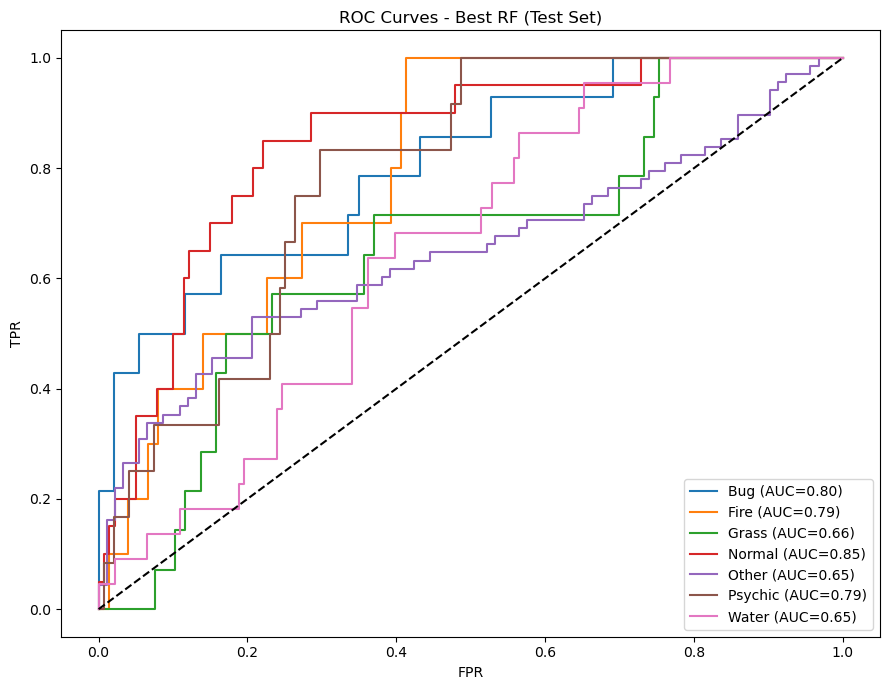

In [35]:
# Create ROC curve plots
classes = list(best_rf.classes_)
y_test_bin = label_binarize(y_test, classes=classes)
y_prob = best_rf.predict_proba(X_test)
fig, ax = plt.subplots(figsize=(9,7))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob[:,i])
    ax.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr,tpr):.2f})")
ax.plot([0,1],[0,1],"k--")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC Curves - Best RF (Test Set)")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

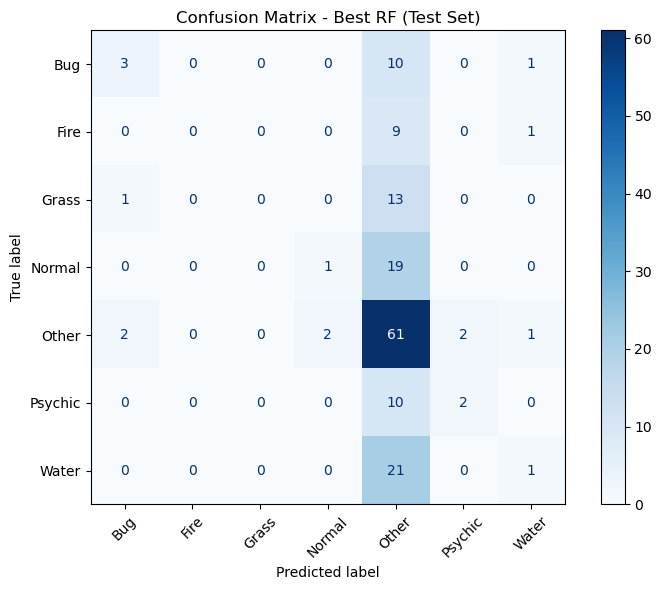

In [36]:
# Create a confusion matrix
y_pred = best_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("Confusion Matrix - Best RF (Test Set)")
plt.tight_layout(); plt.show()

### Question 11
How did your best random forest model do on the testing set?

Which Pokemon types is the model best at predicting, and which is it worst at? (Do you have any ideas why this might be?)



The model achieved a weighted OVR AUC of approximately **0.69** on the test set which is a reasonable performance given the inherent difficulty of predicting Pokémon type from battle stats alone.

**Best predicted types:** **Water** and **Normal** which both have the most training examples and relatively consistent stat profiles. Water types tend to be bulkier; Normal types tend to be balanced.

**Worst predicted types:** **Other** (lumped rare types) and **Psychic**... "Other" is a heterogeneous mix with no cohesive stat pattern, so the model has no consistent signal to learn. Psychic Pokémon have high SP Atk, which overlaps substantially with Fire and Grass types. These results make intuitive sense because a Pokémon's elemental type reflects lore and design decisions that are not fully captured by raw battle statistics.

**AI CITATION:** CLAUDE LLM was used to help with coding the visualizations aswell as creating the preprocess function.